In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [45]:
data = np.array([[2],[14],[6],[7],[17]])
labels = ["A (2)","B (14)","C (6)", "D (7)","E (17)"]

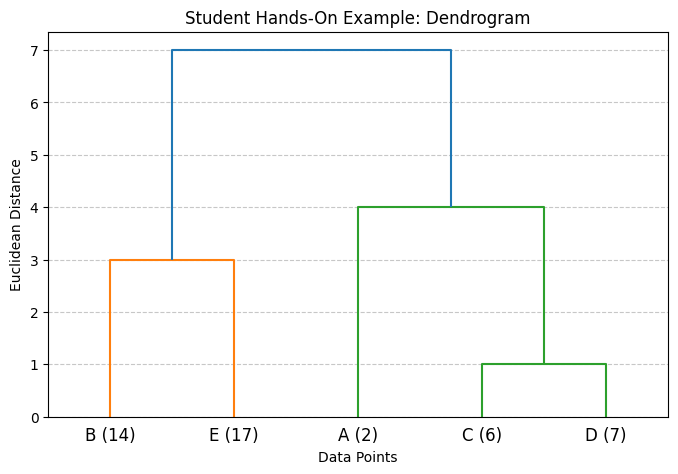

In [46]:
plt.figure(figsize=(8,5))
plt.title("Student Hands-On Example: Dendrogram")

dendrogram = sch.dendrogram(
    sch.linkage(data, method="single", metric = "euclidean"),
    labels=labels)

plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

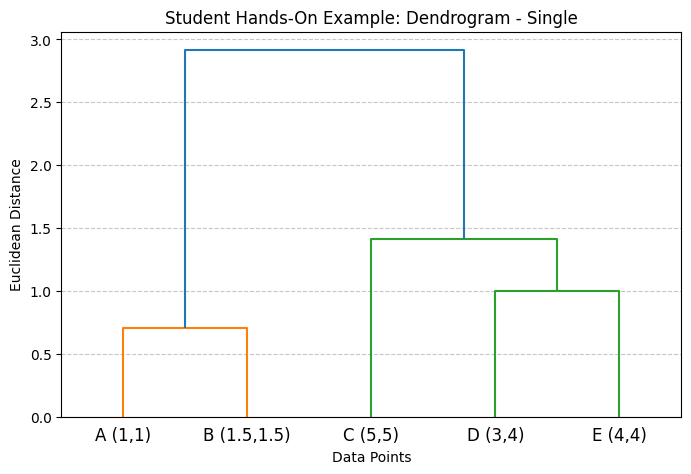

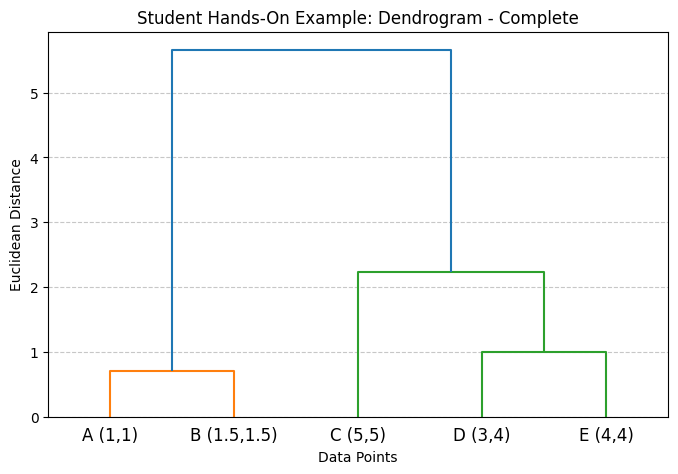

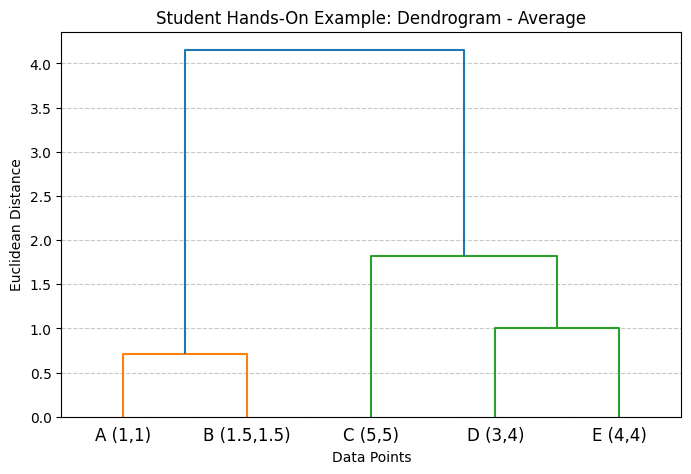

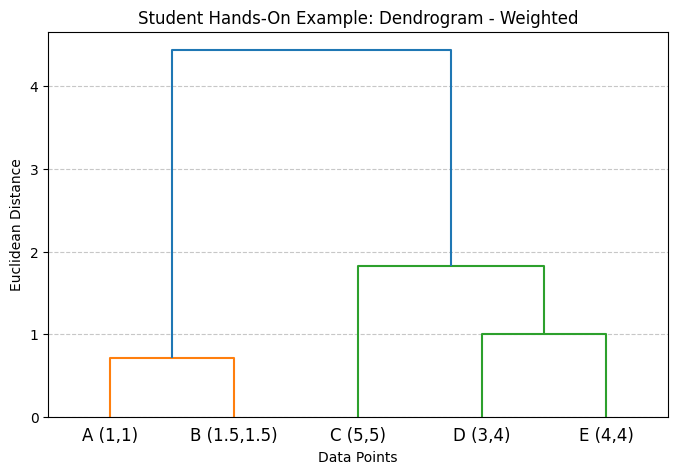

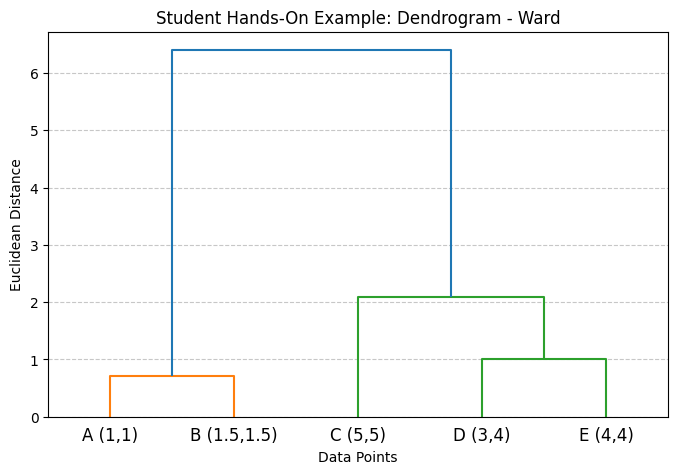

In [47]:
data = np.array([
    [1, 1],
    [1.5, 1.5],
    [5, 5],
    [3, 4],
    [4, 4]
])

labels = ["A (1,1)","B (1.5,1.5)","C (5,5)", "D (3,4)","E (4,4)"]


for i in ["single", "complete", "average", "weighted", "ward"]:
  plt.figure(figsize=(8,5))
  dendrogram = sch.dendrogram(
      sch.linkage(data, method=i, metric = "euclidean"),
      labels=labels)
  plt.title("Student Hands-On Example: Dendrogram - " + i.capitalize())
  plt.xlabel("Data Points")
  plt.ylabel("Euclidean Distance")
  plt.grid(axis='y', linestyle="--", alpha=0.7)
  plt.show()



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

In [49]:
df = pd.read_csv("/content/ecommerce_customers.csv")
df.head()

,CustomerID,Age,Annual_Income_USD,Site_Visits,Total_Spent_USD
0,1,45,120000,12,4500
1,2,42,115000,14,4200
2,3,48,130000,10,4800
3,4,41,110000,15,4100
4,5,47,125000,11,4600


In [50]:
df.drop(columns=["CustomerID"], inplace=True)
df.head()

,Age,Annual_Income_USD,Site_Visits,Total_Spent_USD
0,45,120000,12,4500
1,42,115000,14,4200
2,48,130000,10,4800
3,41,110000,15,4100
4,47,125000,11,4600


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                15 non-null     int64
 1   Annual_Income_USD  15 non-null     int64
 2   Site_Visits        15 non-null     int64
 3   Total_Spent_USD    15 non-null     int64
dtypes: int64(4)
memory usage: 612.0 bytes


In [52]:
scaler = StandardScaler()
data = scaler.fit_transform(df)

In [53]:
data

array([[ 1.23952824,  1.29321774, -0.58388999,  1.42947053],
       [ 0.94749279,  1.17636071, -0.46308516,  1.26796871],
       [ 1.53156369,  1.52693179, -0.70469481,  1.59097235],
       [ 0.85014764,  1.05950369, -0.40268275,  1.21413477],
       [ 1.43421854,  1.41007476, -0.6442924 ,  1.48330447],
       [-1.29144565, -1.16077978,  1.40938962, -0.85847188],
       [-1.09675535, -1.09066556,  1.71140169, -0.83155491],
       [-1.1941005 , -1.13740837,  1.22818239, -0.88000546],
       [-0.9994102 , -1.04392275,  0.98657274, -0.82078813],
       [-1.3887908 , -1.18415118,  1.59059686, -0.89077225],
       [-0.02595871, -0.22592358, -0.82549964, -0.56238522],
       [ 0.26607674, -0.10906656, -0.70469481, -0.48163431],
       [-0.31799416, -0.2960378 , -0.94630446, -0.61621916],
       [-0.12330386, -0.15580937, -0.88590205, -0.53546825],
       [ 0.16873159, -0.06232375, -0.76509722, -0.50855128]])

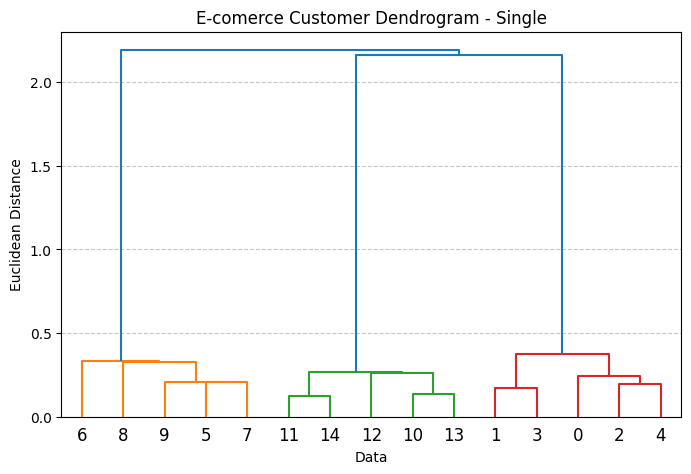

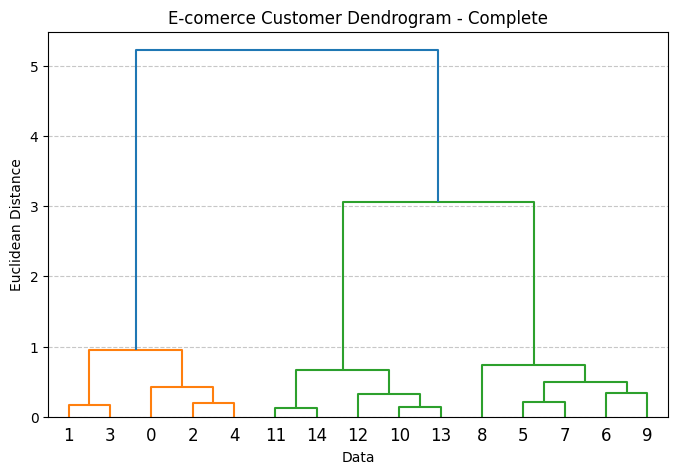

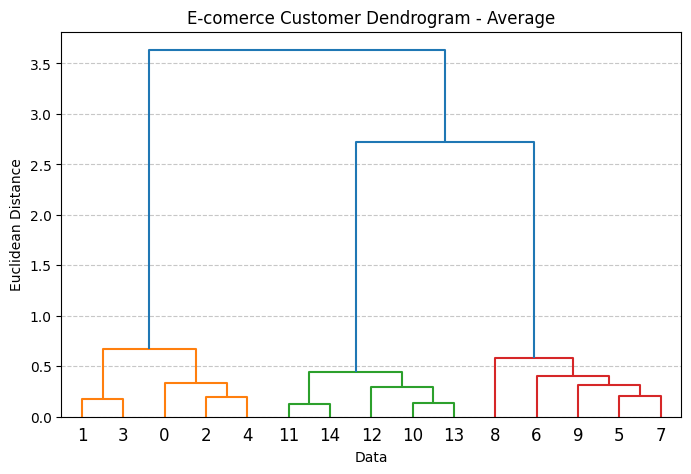

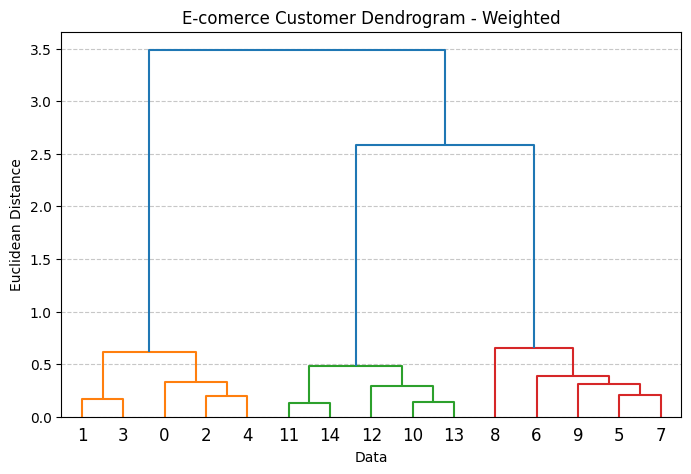

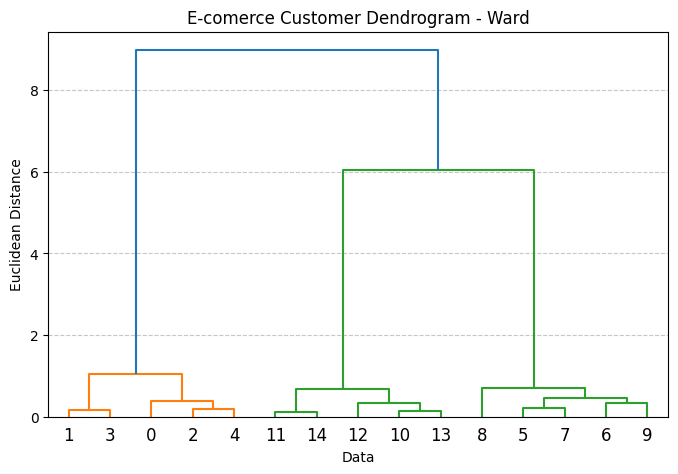

In [54]:
for i in ["single", "complete", "average", "weighted","ward"]:
  plt.figure(figsize=(8,5))
  dendrogram = sch.dendrogram(
      sch.linkage(data, method=i))
  plt.title("E-comerce Customer Dendrogram - " + i.capitalize())
  plt.xlabel("Data")
  plt.axhline(y=40000, color='r', linestyle='--')
  plt.ylabel("Euclidean Distance")
  plt.grid(axis='y', linestyle="--", alpha=0.7)
  plt.show()

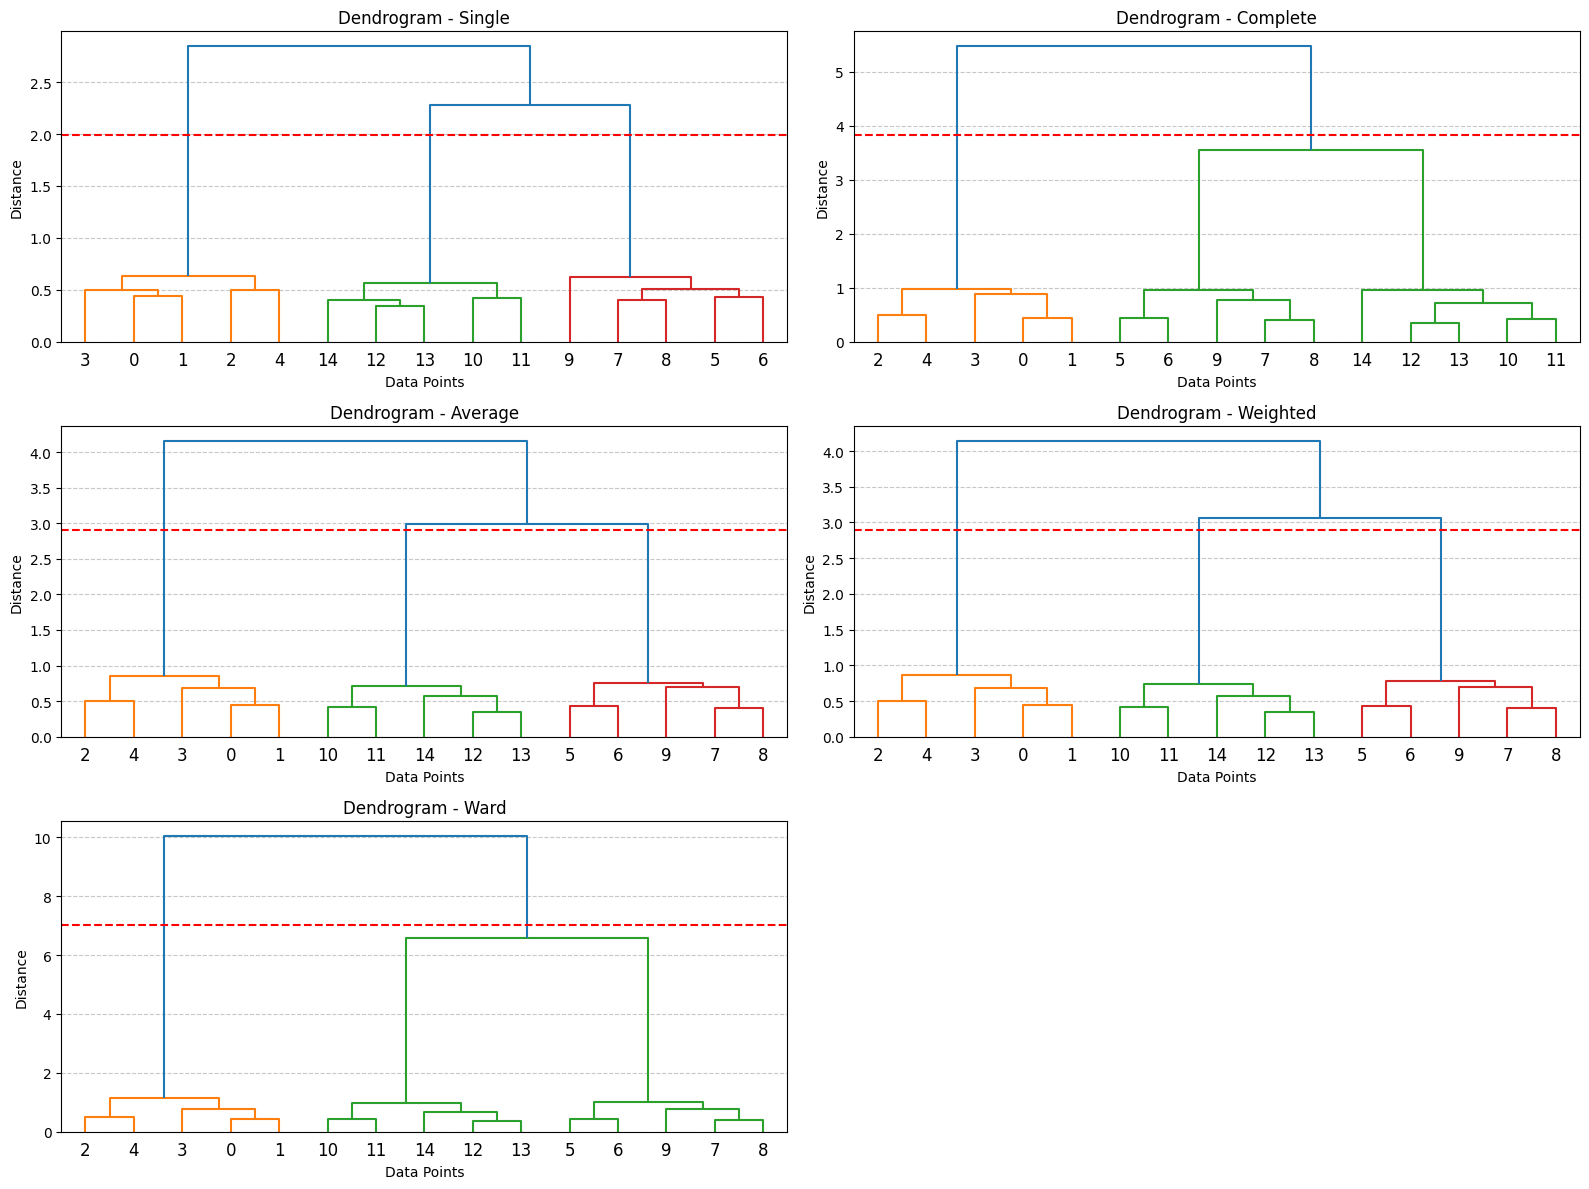

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("/content/ecommerce_customers.csv")

# Keep only numeric features
data = df.select_dtypes(include=[np.number]).values

# -----------------------------
# 2. Standardize data
# -----------------------------
scaler = StandardScaler()
data = scaler.fit_transform(data)

# -----------------------------
# 3. Linkage methods
# -----------------------------
methods = ["single", "complete", "average", "weighted", "ward"]

# -----------------------------
# 4. Create subplots
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, method in enumerate(methods):
    ax = axes[i]

    Z = sch.linkage(data, method=method)

    sch.dendrogram(
        Z,
        ax=ax,
    )

    # Title and labels
    ax.set_title(f"Dendrogram - {method.capitalize()}")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")

    # Dynamic cutoff line (IMPORTANT)
    cutoff = 0.7 * max(Z[:, 2])
    ax.axhline(y=cutoff, color='r', linestyle='--')

    ax.grid(axis='y', linestyle="--", alpha=0.7)

# Remove empty subplot (since 6 slots, 5 used)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [59]:
df

,CustomerID,Age,Annual_Income_USD,Site_Visits,Total_Spent_USD
0,1,45,120000,12,4500
1,2,42,115000,14,4200
2,3,48,130000,10,4800
3,4,41,110000,15,4100
4,5,47,125000,11,4600
5,6,19,15000,45,250
6,7,21,18000,50,300
7,8,20,16000,42,210
8,9,22,20000,38,320
9,10,18,14000,48,190
